## Lab16: Clasificación con Random Forest

**Objetivo de la práctica:**  
Construir un modelo de clasificación utilizando el algoritmo **Random Forest** para predecir la especie de una flor del dataset Iris.

En esta práctica se toma como referencia la estructura del Lab13, pero se cambia el algoritmo KNN por **Random Forest Classifier**.  
La práctica incluye carga de datos, exploración, preparación, entrenamiento, predicción, evaluación del modelo e interpretación mediante importancia de variables.

## 1. Carga de librerías

En esta sección se importan las librerías necesarias para trabajar con datos, crear gráficas, dividir el dataset, entrenar el modelo y evaluar los resultados.

In [1]:
# Librerías principales para manejo de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt

# Herramientas de Scikit-Learn para cargar datos y dividir el conjunto
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Modelo Random Forest para clasificación
from sklearn.ensemble import RandomForestClassifier

# Métricas para evaluar el desempeño del modelo
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Configuración general para que las gráficas se vean mejor
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 2. Carga del dataset Iris

El dataset **Iris** contiene mediciones de flores de tres especies diferentes:

- Setosa
- Versicolor
- Virginica

Cada registro tiene características como largo y ancho del sépalo, además de largo y ancho del pétalo.

In [2]:
# Cargamos el dataset Iris desde Scikit-Learn
# as_frame=True permite obtener los datos directamente como DataFrame de pandas
iris = load_iris(as_frame=True)

# Mostramos la descripción general del dataset
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [3]:
# Convertimos el dataset completo en un DataFrame
df_iris = iris.frame

# Visualizamos las primeras filas para conocer la estructura del conjunto de datos
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Exploración inicial del conjunto de datos

Antes de entrenar un modelo es importante revisar:

- Cantidad de filas y columnas.
- Nombres de las columnas.
- Tipos de datos.
- Valores nulos.
- Distribución de la variable objetivo.

In [4]:
# Revisamos la dimensión del dataset
# El resultado se interpreta como: (filas, columnas)
df_iris.shape

(150, 5)

In [5]:
# Mostramos el nombre de todas las columnas
df_iris.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [6]:
# Revisamos información general:
# tipo de dato de cada columna y cantidad de valores no nulos
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [7]:
# Revisamos si existen valores nulos en cada columna
df_iris.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [8]:
# Mostramos las estadísticas descriptivas de las variables numéricas
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 4. Renombrar y transformar la variable objetivo

La columna original llamada **target** contiene números:

- 0
- 1
- 2

Para que el análisis sea más claro, se transforman esos números a los nombres reales de las especies.

In [9]:
# Renombramos la columna target a especies para que sea más entendible
df_iris.rename(columns={"target": "especies"}, inplace=True)

# Convertimos los valores numéricos en nombres de especies
df_iris["especies"] = df_iris["especies"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Verificamos los cambios en las últimas filas
df_iris.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especies
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [10]:
# Revisamos cuántos ejemplos existen por cada especie
# Esto ayuda a saber si el dataset está balanceado
df_iris["especies"].value_counts()

especies
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

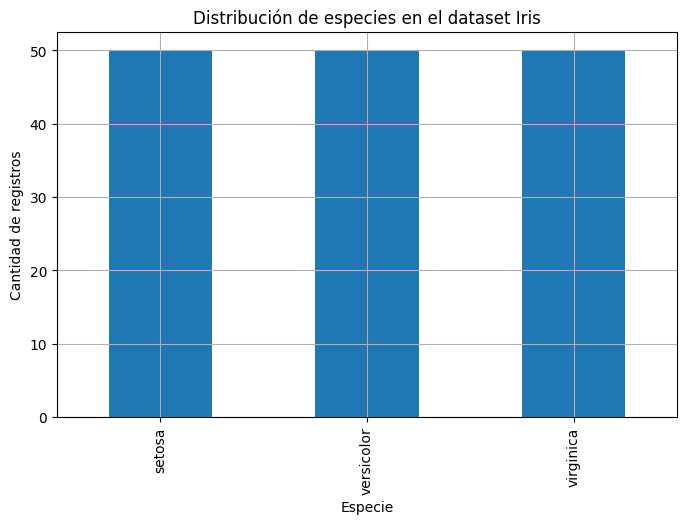

In [11]:
# Gráfica de distribución de clases
# Sirve para observar visualmente si las clases están equilibradas
df_iris["especies"].value_counts().plot(kind="bar")

plt.title("Distribución de especies en el dataset Iris")
plt.xlabel("Especie")
plt.ylabel("Cantidad de registros")
plt.show()

## 5. Identificación de variables predictoras y variable objetivo

Para entrenar un modelo de Machine Learning se necesita separar:

- **X:** variables predictoras o características.
- **y:** variable objetivo o etiqueta que se desea predecir.

En este caso, se busca predecir la especie de la flor con base en sus mediciones.

In [12]:
# Variables predictoras:
# Se eliminan las especies porque esa es la respuesta que el modelo debe aprender a predecir
X = df_iris.drop(columns=["especies"])

# Variable objetivo:
# Contiene la especie real de cada flor
y = df_iris["especies"]

In [13]:
print("Variables predictoras:")
print(X.columns)

print("\nVariable objetivo:")
print(y.name)

Variables predictoras:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

Variable objetivo:
especies


In [14]:
# Visualizamos las primeras filas de las variables predictoras
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [15]:
# Visualizamos las primeras etiquetas de la variable objetivo
y.head()

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: especies, dtype: object

## 6. División de datos en entrenamiento y prueba

El dataset se divide en dos partes:

- **80% para entrenamiento:** el modelo aprende con estos datos.
- **20% para prueba:** se evalúa si el modelo puede clasificar datos que no vio durante el entrenamiento.

Se utiliza `stratify=y` para conservar la proporción de especies en ambos conjuntos.

In [16]:
# Dividimos los datos en entrenamiento y prueba
# random_state permite que los resultados sean reproducibles
# stratify conserva el equilibrio de clases en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

In [17]:
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (120, 4)
Tamaño de X_test: (30, 4)
Tamaño de y_train: (120,)
Tamaño de y_test: (30,)


## 7. Nota sobre el escalado de variables


En **Random Forest**, el escalado no es obligatorio porque el algoritmo trabaja con árboles de decisión.  
Los árboles dividen los datos usando reglas como:

> petal length <= 2.45

Por esa razón, en esta práctica se entrena el modelo con las variables originales.

In [18]:
# Mostramos un ejemplo de los datos sin escalar
# Random Forest puede trabajar correctamente con estos valores originales
X_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
8,4.4,2.9,1.4,0.2
106,4.9,2.5,4.5,1.7
76,6.8,2.8,4.8,1.4
9,4.9,3.1,1.5,0.1
89,5.5,2.5,4.0,1.3


## 8. Entrenamiento del modelo Random Forest

Random Forest es un algoritmo que combina varios árboles de decisión.  
Cada árbol aprende una parte del problema y al final se toma una decisión conjunta.

Parámetros utilizados:

- `n_estimators=100`: número de árboles del bosque.
- `random_state=42`: permite obtener resultados reproducibles.
- `max_depth=None`: los árboles pueden crecer hasta donde sea necesario.
- `criterion="gini"`: medida usada para decidir las divisiones de los árboles.

In [19]:
# Creamos el modelo Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=100,     # número de árboles en el bosque
    criterion="gini",     # criterio para medir la calidad de las divisiones
    max_depth=None,       # sin límite fijo de profundidad
    random_state=42       # semilla para reproducir resultados
)

# Entrenamos el modelo con los datos de entrenamiento
modelo_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## 9. Realizar predicciones con los datos de prueba

Después de entrenar el modelo, se utilizan los datos de prueba para generar predicciones.  
Estos datos no fueron usados durante el entrenamiento, por eso ayudan a medir el desempeño real del modelo.

In [20]:
# Realizamos predicciones usando las variables de prueba
prediccion_rf = modelo_rf.predict(X_test)

# Mostramos las primeras 10 predicciones
print(prediccion_rf[:10])

['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor']


## 10. Comparación entre valores reales y valores predichos

Esta tabla permite observar directamente qué especie era la correcta y cuál fue la predicha por el modelo.

In [21]:
# Creamos un DataFrame para comparar la respuesta real contra la predicción del modelo
comparacion = pd.DataFrame({
    "especie_real": y_test.values,
    "especie_predicha": prediccion_rf
})

# Agregamos una columna para identificar si el modelo acertó o se equivocó
comparacion["resultado"] = np.where(
    comparacion["especie_real"] == comparacion["especie_predicha"],
    "Correcto",
    "Incorrecto"
)

comparacion.head(30)

,especie_real,especie_predicha,resultado
0,setosa,setosa,Correcto
1,virginica,virginica,Correcto
2,versicolor,versicolor,Correcto
3,versicolor,versicolor,Correcto
4,setosa,setosa,Correcto
5,versicolor,versicolor,Correcto
6,setosa,setosa,Correcto
7,setosa,setosa,Correcto
8,virginica,virginica,Correcto
9,versicolor,versicolor,Correcto


In [22]:
# Contamos cuántas predicciones fueron correctas e incorrectas
comparacion["resultado"].value_counts()

resultado
Correcto      27
Incorrecto     3
Name: count, dtype: int64

## 11. Evaluación del modelo

La evaluación permite conocer qué tan bien está clasificando el modelo.

Se utilizan tres herramientas principales:

1. **Accuracy:** porcentaje general de aciertos.
2. **Matriz de confusión:** muestra aciertos y errores por clase.
3. **Classification report:** incluye precision, recall, f1-score y support.

In [23]:
# Calculamos la exactitud del modelo
accuracy = accuracy_score(y_test, prediccion_rf)

print(f"Accuracy / Exactitud del modelo: {accuracy:.4f}")

Accuracy / Exactitud del modelo: 0.9000


## 12. Matriz de confusión

La matriz de confusión muestra cuántas flores fueron clasificadas correctamente y en qué clases hubo errores.

- La diagonal principal representa los aciertos.
- Los valores fuera de la diagonal representan errores de clasificación.

In [24]:
# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, prediccion_rf, labels=modelo_rf.classes_)

# Convertimos la matriz en DataFrame para verla como tabla
cm_df = pd.DataFrame(
    cm,
    index=modelo_rf.classes_,
    columns=modelo_rf.classes_
)

cm_df

,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,9,1
virginica,0,2,8


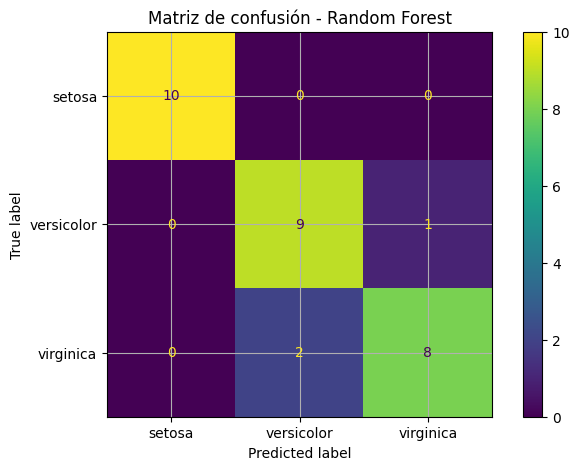

In [25]:
# Mostramos la matriz de confusión de forma gráfica
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo_rf.classes_
)

disp.plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()

## 13. Classification report

El reporte de clasificación permite evaluar el desempeño por cada especie.

Métricas principales:

- **Precision:** de las predicciones hechas para una clase, cuántas fueron correctas.
- **Recall:** de todos los casos reales de una clase, cuántos detectó correctamente.
- **F1-score:** equilibrio entre precision y recall.
- **Support:** cantidad de datos reales por clase.

In [26]:
# Generamos el reporte completo de clasificación
print(classification_report(y_test, prediccion_rf))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



## 14. Importancia de las variables

Una ventaja de Random Forest es que permite estimar qué variables fueron más importantes para clasificar las flores.

Esto ayuda a interpretar el modelo y entender qué características influyen más en la predicción.

In [27]:
# Obtenemos la importancia de cada variable utilizada por el modelo
importancias = modelo_rf.feature_importances_

# Creamos un DataFrame para ordenar e interpretar mejor los resultados
df_importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia": importancias
}).sort_values(by="importancia", ascending=False)

df_importancias

,variable,importancia
3,petal width (cm),0.437185
2,petal length (cm),0.431466
0,sepal length (cm),0.116349
1,sepal width (cm),0.015000


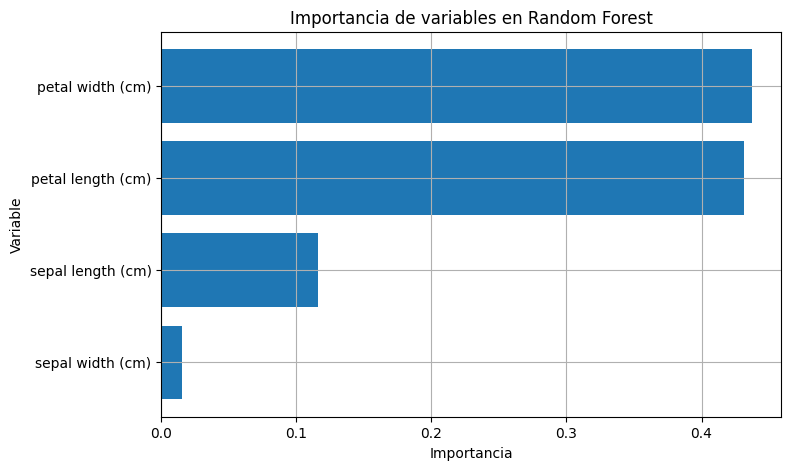

In [28]:
# Graficamos la importancia de variables
plt.barh(df_importancias["variable"], df_importancias["importancia"])
plt.title("Importancia de variables en Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
plt.show()

## 15. Predicción con un nuevo ejemplo

Ahora se puede usar el modelo entrenado para clasificar una nueva flor con medidas inventadas.

El orden de las variables debe ser el mismo que en el dataset original.

In [29]:
# Creamos un nuevo ejemplo con las mismas variables del dataset
nueva_flor = pd.DataFrame({
    "sepal length (cm)": [5.1],
    "sepal width (cm)": [3.5],
    "petal length (cm)": [1.4],
    "petal width (cm)": [0.2]
})

# Realizamos la predicción
prediccion_nueva = modelo_rf.predict(nueva_flor)

print("La especie predicha para la nueva flor es:", prediccion_nueva[0])

La especie predicha para la nueva flor es: setosa


## 16. Conclusión de la práctica

En esta práctica se construyó un modelo de clasificación usando **Random Forest** con el dataset Iris.

El proceso realizado fue:

1. Cargar librerías y dataset.
2. Explorar los datos.
3. Renombrar y preparar la variable objetivo.
4. Separar variables predictoras y variable objetivo.
5. Dividir datos en entrenamiento y prueba.
6. Entrenar el modelo Random Forest.
7. Realizar predicciones.
8. Evaluar el modelo con accuracy, matriz de confusión y classification report.
9. Interpretar la importancia de las variables.

Random Forest demostró ser un algoritmo eficiente para tareas de clasificación, ya que combina varios árboles de decisión para obtener resultados más estables y reducir el riesgo de errores individuales. Además, una de sus principales ventajas es que permite analizar la importancia de las variables, lo cual ayuda a identificar qué características tienen mayor influencia en la predicción final.

En conclusión, esta práctica permitió comprender de manera clara cómo se aplica un modelo de aprendizaje supervisado para resolver un problema de clasificación. También se comprobó la importancia de preparar correctamente los datos, entrenar el modelo de forma adecuada y evaluar sus resultados antes de considerarlo útil para realizar predicciones.

In [30]:
# Resumen final de resultados
print("Resumen de la práctica con Random Forest")
print("---------------------------------------")
print(f"Exactitud del modelo: {accuracy:.4f}")
print(f"Número de árboles utilizados: {modelo_rf.n_estimators}")
print("Variables utilizadas:")
for variable in X.columns:
    print("-", variable)

Resumen de la práctica con Random Forest
---------------------------------------
Exactitud del modelo: 0.9000
Número de árboles utilizados: 100
Variables utilizadas:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)
